# Grids of SNEC models
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [1]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import (SNEC_output_parser, plot_vel_radius_at_time_t,
                      plot_mass_radius, plot_v_radius_time, get_times, sci_to_latex,
                      plot_LC)
import astropy.units as u
import glob
from itertools import cycle
%load_ext autoreload
%autoreload 2

Hardcoded some constants


In [2]:
tmax = 24*u.h

# define colormap -- to use time in hours as color value
Ncolors = 100
colors = plt.get_cmap('viridis', Ncolors)
norm = mpl.colors.Normalize(vmin=0,vmax=tmax.to(u.h).value)

sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
sm.set_array([])


In [3]:
def get_energy_from_folder(folder):
    return float(folder.split("_e_")[-1].rstrip("/").replace("d", "e"))

In [10]:
root = "/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/" # 15Msun_progenitor/ # s30VdJNL_0.33/"
models = sorted(glob.glob(root+"*.*/"), key=get_energy_from_folder)
print(models)
print(len(models))
BE = 0.64589366106874414e51 *u.erg # see Table 2 in Morozova et al. 2015

['/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_0.0d0/', '/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/']
2


/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_0.0d0/


/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/


/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  func(*args, **kwargs)


/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


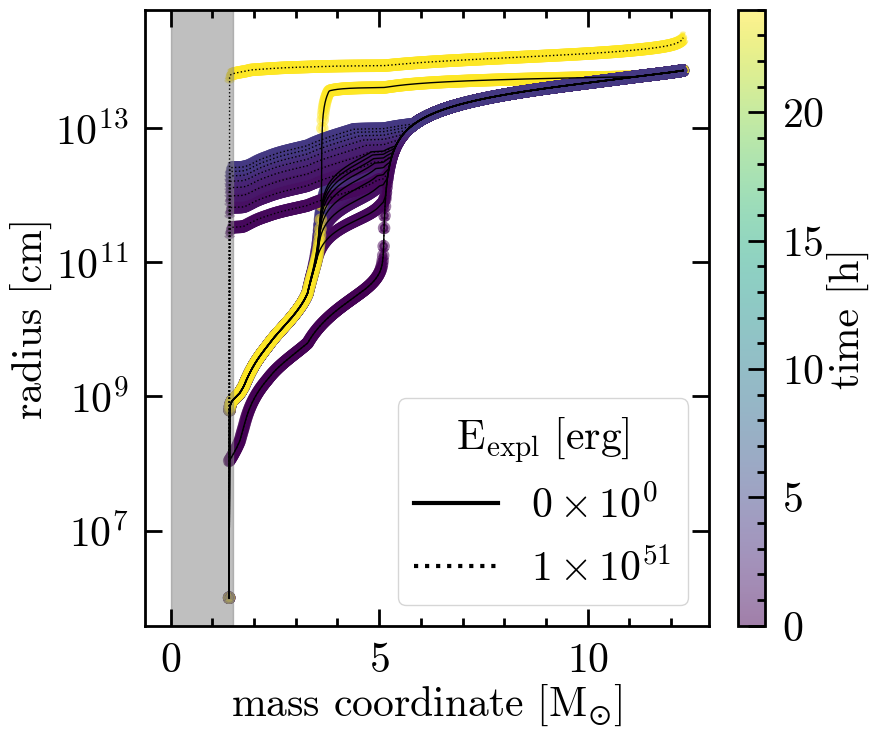

In [11]:
fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])
cax = fig.add_subplot(gs[:, 105:])

bomb_spread = 0.1 *u.Msun #  see parameters file
# colors = plt.cm.viridis(np.linspace(0,1,len(models)))
linestyles = ["-", ":"]
   #  (0, (1, 10)),
   #  # (0, (1, 5)),
   #  (0, (1, 1)),
    
   #  # (5, (10, 3)),
   #  (0, (5, 10)),
   #  # (0, (5, 5)),
   #  (0, (5, 1)),
    
   #  # (0, (3, 10, 1, 10)),
   #  (0, (3, 5, 1, 5)),
   # ]

for j, m in enumerate([models[0], models[-1]]):
    print(m)
    if True: #try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times[::10]):
            m, r, p = plot_mass_radius(t, outfile, ax=ax, scatter=True,
                                       alpha=0.25, # s=10*(1+i),
                                       # color=colors[j],
                                       ls = linestyles[j],                                       
                                       # label = f"{t.to(u.h).value:.1f}",
                                       lw=3,
                                       vmin = 0,
                                       vmax = tmax.to(u.h).value
                                       )
            xmin = min(m).to(u.Msun).value
            # print(linestyles[j])
            if t >= tmax: break
    # except:
    #     print("FAILED")
    #     pass
plt.colorbar(p, cax=cax, norm=norm)
# ax.legend(frameon=True, ncol=2, columnspacing=0.5, handlelength=0.05, title="time [h]")
ax.axvspan(xmin=0, xmax=xmin+bomb_spread.to(u.Msun).value, alpha=0.5, color="#808080")
# ax.set_xlim(0, 7.0)
ax.set_yscale('log')
# ax.set_yscale('symlog',linthresh=1e12, linscale=0.66)
# ax.set_ylim(1e8, 1e13)
# ax.set_ylim(-1, 2.7e12)
cax.set_ylabel(r"time [h]")
ax.set_xlabel(r"mass coordinate [$M_{\odot}$]")
ax.set_ylabel(r"radius [cm]") #(r"$\log_{10}(r/\mathrm{cm})$")
ax.plot(np.nan, np.nan, c='k', ls='-', label=f"{sci_to_latex(get_energy_from_folder(models[0]))}")
ax.plot(np.nan, np.nan, c='k', ls=':', label=f"{sci_to_latex(get_energy_from_folder(models[-1]))}")
ax.legend(title=r"$E_{\rm expl} \ [\mathrm{erg}]$", frameon=True)

/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.0d0/


/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.25d51/


/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.5d51/


/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.75d51/


/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d51/


Text(0.5, 0, 'Mass coordinate [$M_{\\odot}$]')

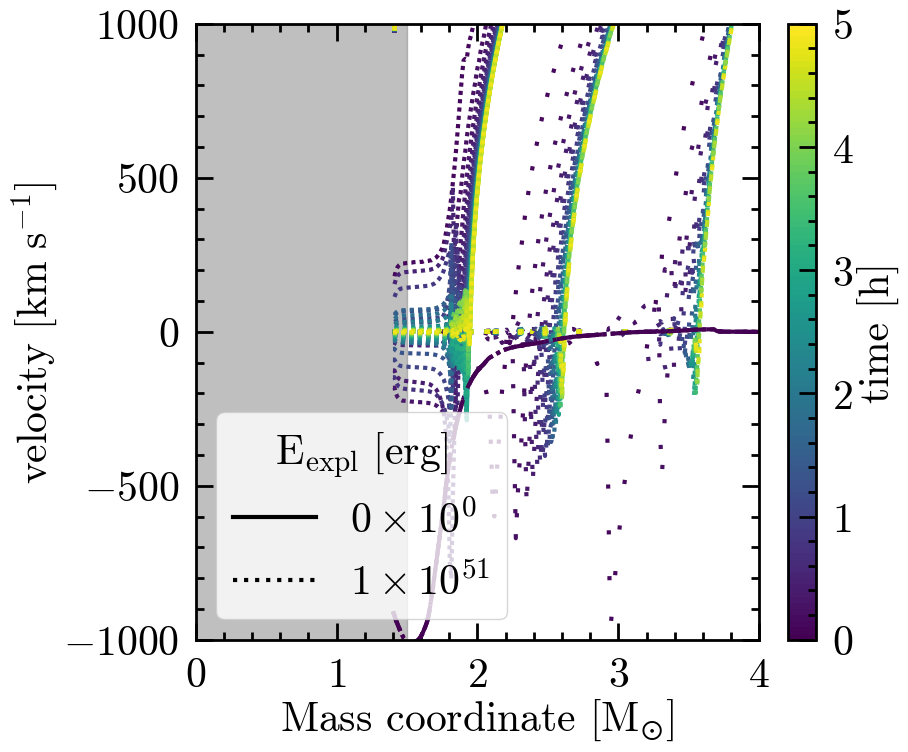

In [26]:
fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])
cax = fig.add_subplot(gs[:, 105:])

ls = linestyles = [
    (0, (1, 10)),
    (0, (1, 5)),
    (0, (1, 1)),
    
    (5, (10, 3)),
    (0, (5, 10)),] # to distinguish models
plt.colorbar(sm, cax=cax, # ticks=np.linspace(0,2,N), 
             # boundaries=np.arange(-0.05,2.1,.1)
             )
cax.set_ylabel(r"time [h]")


for j, m in enumerate(models): # [models[0], models[-1]]):
    print(m)
    times = get_times(m+'Data/mass.xg')
    for i, t in enumerate(times):
        # if t.to(u.d) >= tmax.to(u.d): break
        mm, v, p = plot_vel_radius_at_time_t(t, m+'/Data/vel.xg', ax=ax,
                                             # vmin = min(times[:10].to(u.h).value),
                                             # vmax = max(times[:10].to(u.h).value),
                                             c=colors(norm(t.to(u.h).value)),
                                             ls=ls[j], scatter=False
                                             )

        
ax.plot(np.nan, np.nan, c='k', ls='-', label=f"{sci_to_latex(get_energy_from_folder(models[0]))}")
ax.plot(np.nan, np.nan, c='k', ls=':', label=f"{sci_to_latex(get_energy_from_folder(models[-1]))}")

cax.set_ylabel(r"time [h]")
ax.set_xlim(0,4)
ax.axvspan(xmin=0, xmax=xmin+bomb_spread.to(u.Msun).value, alpha=0.5, color="#808080")
ax.legend(title=r"$E_{\rm expl} \ [\mathrm{erg}]$", frameon=True)
ax.set_ylim(-1000, 1000)
ax.set_ylabel(r"velocity [$\mathrm{km\ s^{-1}}$]")
ax.set_xlabel(r"Mass coordinate [$M_{\odot}$]")

In [ ]:
fig = plt.figure(figsize=(15,20))
gs = gridspec.GridSpec(9, 210)  # 16 rows, 2 cols of plots + colorbar
axes = []
for row in range(9):
    ax_left = fig.add_subplot(gs[row, :100])
    ax_right = fig.add_subplot(gs[row, 100:210])
    axes.append(ax_left)
    axes.append(ax_right)

cax = fig.add_subplot(gs[:, 205:])

bomb_spread = 0.1 *u.Msun #  see parameters file

# for i, ax in enumerate(axes):
#     ax.text(0.5, 0.5, i)

s15 = "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/" # 30Msun_VdJNL/"
models15 = sorted(glob.glob(s15+"*.*/"), key=get_energy_from_folder)
# print(len(models15), models15)
for j, m in enumerate(models15):
    ax = axes[2*j]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times):
            # print(t.to(u.h))
            if t.to(u.h) >= tmax: break
            m, r, p = plot_mass_radius(t, outfile, ax=ax, alpha=0.5, # s=10*(1+i),
                                       # c=colors[j],
                                       # ls = linestyles[j],
                                       label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=tmax.value)
            xmin = min(m.to(u.Msun))               
    except:
        print("FAILED")
        pass

s30 = "/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/"
models30 = sorted(glob.glob(s30+"*.*/"), key=get_energy_from_folder)
# print(len(models30), models30)
for j, m in enumerate(models30):
    ax = axes[2*j+1]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        for i, t in enumerate(times):
            if t.to(u.h) >= tmax: break
            m, r, p = plot_mass_radius(t, outfile, ax=ax, alpha=0.5, # s=10*(1+i),
                                       # c=colors[j],
                                       # ls = linestyles[j],
                                       label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=tmax.value)
            
    except:
        print("FAILED")
        pass
xmin = min(m.to(u.Msun))
plt.colorbar(p, cax=cax)
# ax.legend(frameon=True, ncol=2, columnspacing=0.5, handlelength=0.05, title="time [h]")

for i, ax in enumerate(axes):
    # ax.set_xlim(0, 5.0)
    ax.set_yscale('log')
    if (i%2 !=0): ax.set_yticklabels([])
    if (i != 16) and (i !=17): ax.set_xticklabels([])
    
axes[0].set_title(r"$15M_{\odot}$ RSG", size=30)
axes[1].set_title(r"$30M_{\odot}$ WR", size=30)
axes[16].set_xlabel(r"mass coordinate [$M_{\odot}$]")
axes[17].set_xlabel(r"mass coordinate [$M_{\odot}$]")
cax.set_ylabel(r"time [h]")
# ax.set_xlabel(r"mass coordinate [$M_{\odot}$]")
# ax.set_ylabel(r"radius [cm]") #(r"$\log_{10}(r/\mathrm{cm})$") 

In [ ]:
fig = plt.figure(figsize=(20,30))
gs = gridspec.GridSpec(9, 210)  # 16 rows, 2 cols of plots + colorbar
axes = []
for row in range(9):
    ax_left = fig.add_subplot(gs[row, :100])
    ax_right = fig.add_subplot(gs[row, 100:210])
    axes.append(ax_left)
    axes.append(ax_right)

cax = fig.add_subplot(gs[:, 205:])

bomb_spread = 0.1 *u.Msun #  see parameters file

# for i, ax in enumerate(axes):
#     ax.text(0.5, 0.5, i)

s15 = "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/" # 30Msun_VdJNL/"
models15 = sorted(glob.glob(s15+"*/*.*/"), key=get_energy_from_folder)

for j, m in enumerate(models15):
    ax = axes[2*j]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        vel_file = m+'Data/vel.xg'
        mass_file = m+'Data/mass.xg'
        times = get_times(vel_file)
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times[::10]):           
            m, r, p = plot_v_radius_time(t, vel_file, mass_file,
                                         ax=ax, alpha=0.5, # s=10*(1+i),
                                         # c=colors[j],
                                         # ls = linestyles[j],
                                         label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=240)
            xmin = min(m.to(u.Msun))
    except:
        print("FAILED")
        pass


0.0 erg / s 1.8465690797e+38 erg / s
0.0 erg / s 1.8520701979e+38 erg / s
0.0 erg / s 1.8520217775e+38 erg / s
0.0 erg / s 1.8519933219e+38 erg / s
0.0 erg / s 1.8520288688e+38 erg / s


Text(0, 0.5, '$\\log_{10}(L/\\mathrm{[erg\\ s^{-1}]})$')

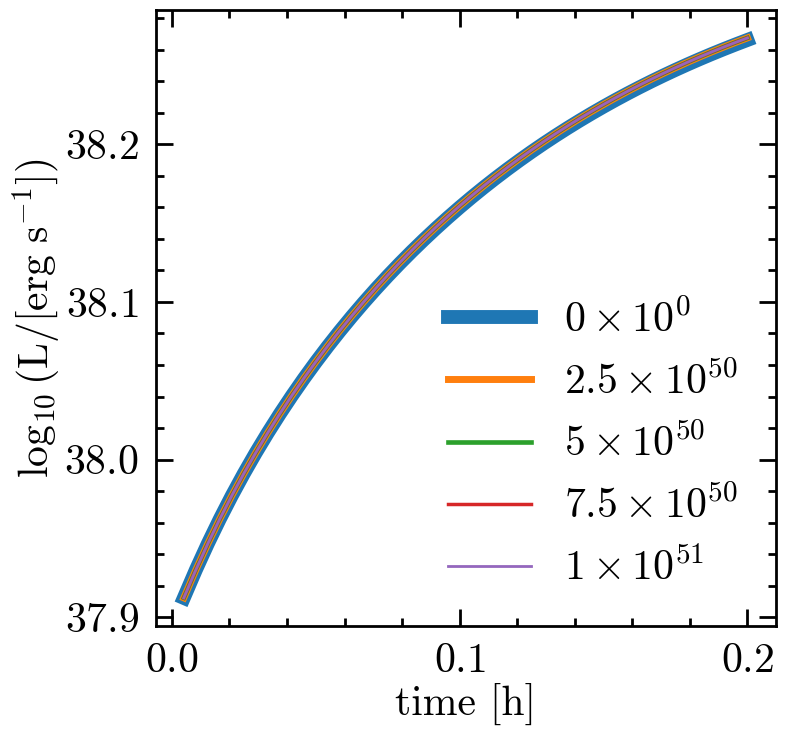

In [56]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for i, m in enumerate(models):
    # try:
    fname = m+'/Data/lum_observed.dat'
    L, t = plot_LC(fname, ax=ax, label=sci_to_latex(get_energy_from_folder(m)), lw=10/(i+1))
    print(min(L), max(L))
    # except: # IndexError:
    #     pass
    #    print(m, "failed")
    
ax.legend()
ax.set_xlabel(r"time [h]")
ax.set_ylabel(r"$\log_{10}(L/\mathrm{[erg\ s^{-1}]})$")

In [29]:
# sorted(glob.glob(root+'/test/*.*/'), key=get_energy_from_folder)

['/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor//test/bomb_final_e_0.25d51/',
 '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor//test/bomb_final_e_0.5d51/',
 '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor//test/bomb_final_e_0.75d51/',
 '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor//test/bomb_final_e_1.0d51/']